In [19]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chart settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

In [31]:
# Collecting all metric files from the project folder
metric_files = glob.glob("metrics_*.csv")

if metric_files:
    dfs = [pd.read_csv(f) for f in metric_files]
    df_metrics = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(metric_files)} metric files. Total number of records: {len(df_metrics)}")
    display(df_metrics.head())
else:
    print("The metrics_*.csv files were not found in the current directory.")

Loaded 5 metric files. Total number of records: 2780


,Subreddit,Submissions Count,Comments Count,Total Activity,Month
0,sportsbook,2111,77622,79733,2024-08
1,sportsbetting,10737,43300,54037,2024-08
2,poker,2597,45027,47624,2024-08
3,pokerogue,3499,31887,35386,2024-08
4,gambling,1679,12062,13741,2024-08


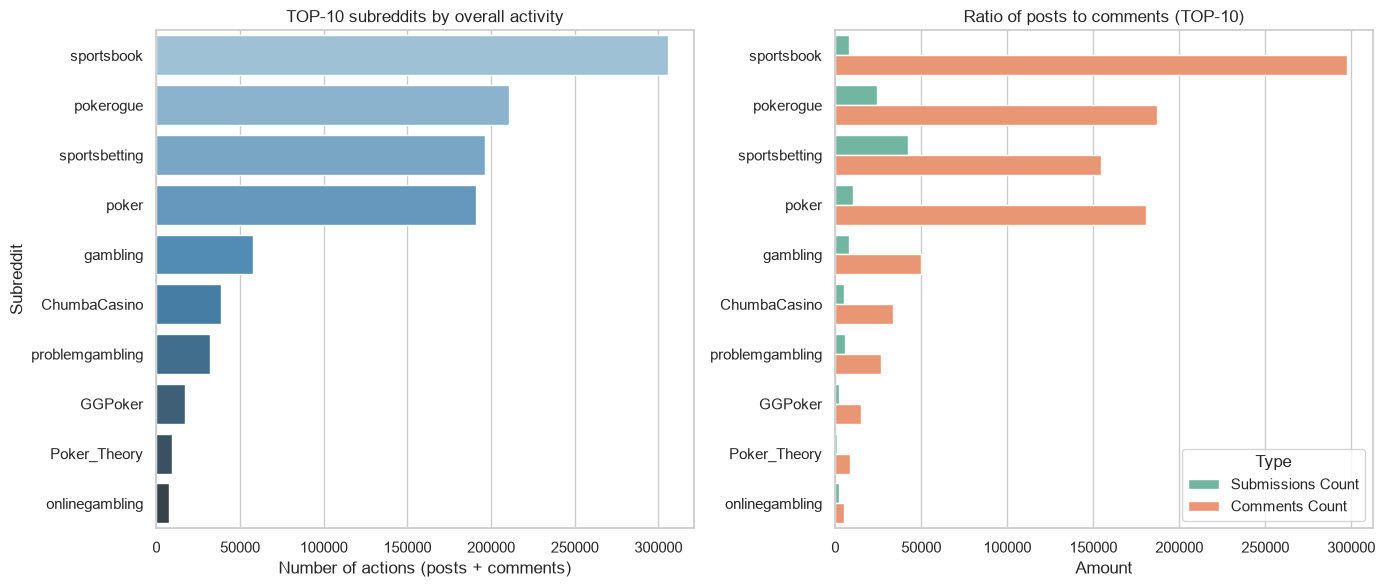

In [32]:
# We take the TOP-10 most active subreddits by total activity
df_top = df_metrics.groupby("Subreddit", as_index=False).agg({
    "Submissions Count": "sum",
    "Comments Count": "sum",
    "Total Activity": "sum"
}).sort_values(by="Total Activity", ascending=False).head(10)

# Adjusting chart size
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Overall activity (TOP-10)
sns.barplot(
    data=df_top,
    x="Total Activity",
    y="Subreddit",
    hue="Subreddit",
    legend=False,
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("TOP-10 subreddits by overall activity")
axes[0].set_xlabel("Number of actions (posts + comments)")
axes[0].set_ylabel("Subreddit")

# Chart 2: Comparison of posts and comments
df_top_melted = df_top.melt(
    id_vars=["Subreddit"],
    value_vars=["Submissions Count", "Comments Count"],
    var_name="Type",
    value_name="Count"
)

sns.barplot(
    data=df_top_melted,
    x="Count",
    y="Subreddit",
    hue="Type",
    ax=axes[1],
    palette="Set2"
)
axes[1].set_title("Ratio of posts to comments (TOP-10)")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [33]:
# Reading filtered Reddit data (e.g., RC_2024-07.csv)
filtered_data_files = glob.glob("RC_*.csv") + glob.glob("RS_*.csv")

if filtered_data_files:
    df_reddit = pd.read_csv(filtered_data_files[0])
    print(f"Results file uploaded: {filtered_data_files[0]}")
    print(f"Number of filtered records: {len(df_reddit)}")

    # If the 'subreddit' column exists — generate the TOP-10 subreddits
    if "subreddit" in df_reddit.columns:
        plt.figure(figsize=(10, 5))
        top_subreddits = df_reddit["subreddit"].value_counts().head(10)
        top_subreddits.plot(kind="barh", color="skyblue").invert_yaxis()
        plt.title("ТОП-10 of the most popular subreddits in the sample")
        plt.xlabel("Number of posts/comments")
        plt.ylabel("Subreddit")
        plt.show()
else:
    print("Filtered CSV files from Reddit were not found.")

Filtered CSV files from Reddit were not found.


In [34]:
print("PROJECT SUMMARY STATISTICS")

if 'df_metrics' in locals() and not df_metrics.empty:
    # Overall results for the entire dataset
    total_subreddits = df_metrics["Subreddit"].nunique()
    total_posts = df_metrics["Submissions Count"].sum()
    total_comments = df_metrics["Comments Count"].sum()
    total_activity = df_metrics["Total Activity"].sum()

    print(f"Total number of unique subreddits: {total_subreddits}")
    print(f"Total posts: {total_posts:,}")
    print(f"Total comments: {total_comments:,}")
    print(f"Total combined activity: {total_activity:,}\n")

    # Aggregation of the TOP-5 most active subreddits
    summary = df_metrics.groupby("Subreddit").agg({
        "Submissions Count": "sum",
        "Comments Count": "sum",
        "Total Activity": "sum"
    }).sort_values(by="Total Activity", ascending=False).head(5)

    print("ТОП-5 most active subreddits:")
    display(summary)

PROJECT SUMMARY STATISTICS
Total number of unique subreddits: 1453
Total posts: 159,857
Total comments: 1,006,021
Total combined activity: 1,165,878

ТОП-5 most active subreddits:


,Submissions Count,Comments Count,Total Activity
Subreddit,,,
sportsbook,8228,297505,305733
pokerogue,24013,186954,210967
sportsbetting,42193,154308,196501
poker,10366,180852,191218
gambling,8059,49762,57821
